In [1]:
import dask.array as da
import joblib
import xarray as xr
from dask_ml.wrappers import ParallelPostFit
from datacube.utils.geometry import assign_crs
from xarray import Dataset
from pystac_client import Client
from odc.stac import load
import os
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rasterio.transform import from_origin

from planetary_computer import sign_url

/tmp/ipykernel_3556/2887921316.py:5: DeprecationWarning: datacube.utils.geometry is now deprecated. Please use the odc-geo library instead.
  from datacube.utils.geometry import assign_crs


In [2]:
DEP_CATALOG = "https://stac.digitalearthpacific.org"
# DEP_CATALOG = "https://stac.staging.digitalearthpacific.io"
MSPC_CATALOG = "https://planetarycomputer.microsoft.com/api/stac/v1/"

In [3]:
import pystac_client
import planetary_computer
import rioxarray
import stackstac
import rasterio
from rasterio.enums import Resampling

# 1. Define Area of Interest in EPSG:4326 (Dawasamu, Fiji)
bbox_4326 = [178.1994097142462,-17.76701403103968,  178.62296324767527,-17.417357343132508]  # [minx, miny, maxx, maxy]

# 2. Query Planetary Computer STAC
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=bbox_4326
)

items = search.item_collection()
print(f"Found {len(items)} DEM tiles.")

# 3. Stack and Reproject to EPSG:32760 with Square 30m Resolution
da = stackstac.stack(
    items,
    assets=["data"],
    epsg=32760,              # Target UTM Zone 60S
    resolution=30.0,         # Force square 30m x 30m cell size
    resampling=Resampling.bilinear,
    fill_value=-9999.0
)

# 4. Mosaic / Squeeze multi-dimensional array into 2D raster
dem_2d = da.max(dim="time").squeeze()

# 5. Assign clean spatial metadata & NoData
dem_2d = dem_2d.rio.write_crs("EPSG:32760")
dem_2d = dem_2d.rio.write_nodata(-9999.0)

# Replace raw missing values (-32767) with standard -9999
dem_2d = dem_2d.where(dem_2d > -1000, -9999.0)

# 6. Export Cloud-Optimized GeoTIFF for InVEST & Notebook Rendering
dem_2d.rio.to_raster(
    "1-dawasamu-dem.tif",
    driver="GTiff",
    dtype="float32",
    compress="lzw",
    tiled=True
)

print("DEM successfully generated and saved to 1-dawasamu-dem.tif!")

Found 1 DEM tiles.
DEM successfully generated and saved to 1-dawasamu-dem.tif!


In [8]:
import pystac_client
import planetary_computer
import rioxarray
import stackstac
import rasterio
from rasterio.enums import Resampling
from shapely.geometry import shape

# 1. GeoJSON input dictionary
geojson_data = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [178.1994097142462, -17.76701403103968],
            [178.62295992396025, -17.767650085953917],
            [178.62296324767527, -17.417357343132508],
            [178.19879849673822, -17.417379637148272],
            [178.1994097142462, -17.76701403103968]
          ]
        ]
      }
    }
  ]
}

# 2. Extract bounding box [minx, miny, maxx, maxy] dynamically using Shapely
polygon_geom = shape(geojson_data["features"][0]["geometry"])
bbox_4326 = list(polygon_geom.bounds)

print(f"Calculated Bounding Box: {bbox_4326}")

# 3. Query Planetary Computer STAC
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=bbox_4326
)

items = search.item_collection()
print(f"Found {len(items)} DEM tiles.")

# 4. Stack, Reproject to EPSG:32760, and Clip to GeoJSON bounds
da = stackstac.stack(
    items,
    assets=["data"],
    epsg=32760,               # Target UTM Zone 60S
    resolution=30.0,          # Force square 30m cell size
    bounds_latlon=bbox_4326,  # Clips output extent to the GeoJSON bounds
    resampling=Resampling.bilinear,
    fill_value=-9999.0
)

# 5. Mosaic/Squeeze multi-dimensional array into 2D raster
dem_2d = da.max(dim="time").squeeze()

# 6. Assign spatial metadata & NoData
dem_2d = dem_2d.rio.write_crs("EPSG:32760")
dem_2d = dem_2d.rio.write_nodata(-9999.0)

# Replace missing values (< -1000) with standard -9999
dem_2d = dem_2d.where(dem_2d > -1000, -9999.0)

# 7. Export Cloud-Optimized GeoTIFF for InVEST
dem_2d.rio.to_raster(
    "1-dawasamu-dem.tif",
    driver="GTiff",
    dtype="float32",
    compress="lzw",
    tiled=True
)

print("DEM successfully generated and saved to 1-dawasamu-dem.tif!")

Calculated Bounding Box: [178.19879849673822, -17.767650085953917, 178.62296324767527, -17.417357343132508]
Found 1 DEM tiles.
DEM successfully generated and saved to 1-dawasamu-dem.tif!


In [9]:
dem_2d

<xarray.DataArray 'stackstac-2e55d1d5fb29872f3b9362085c55f596' (y: 1305, x: 1511)> Size: 16MB
dask.array<where, shape=(1305, 1511), dtype=float64, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates:
    band            <U4 16B 'data'
  * x               (x) float64 12kB 6.271e+05 6.271e+05 ... 6.723e+05 6.724e+05
  * y               (y) float64 10kB 8.074e+06 8.074e+06 ... 8.035e+06 8.035e+06
    gsd             int64 8B 30
    proj:code       <U9 36B 'EPSG:4326'
    proj:transform  object 8B {0.0, -0.0002777777777777778, -16.9998611111111...
    proj:shape      object 8B {3600}
    platform        <U8 32B 'TanDEM-X'
    title           <U14 56B 'S18_00_E178_00'
    epsg            int64 8B 32760
    spatial_ref     int64 8B 0
Attributes:
    _FillValue:  -9999.0

Text(0.5, 1.0, 'DEM Elevation')

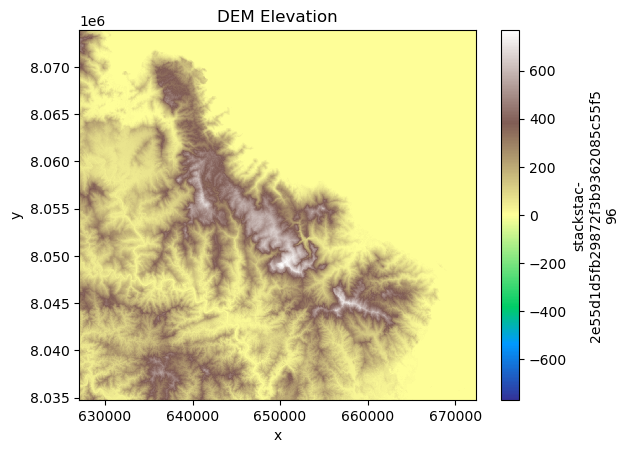

In [10]:
# If you have a DataArray
dem_2d.plot(cmap='terrain')
plt.title("DEM Elevation")
# plt.show()

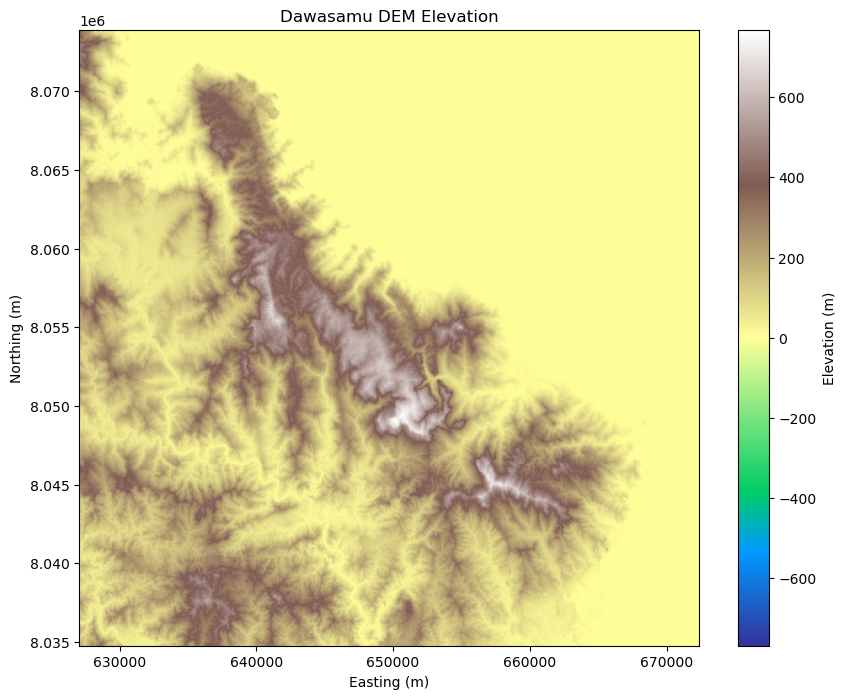

In [11]:
import matplotlib.pyplot as plt

# 1. Mask NoData values (-9999) so they don't corrupt the visual color scale
dem_masked = dem_2d.where(dem_2d != -9999.0)

# 2. Plot directly
plt.figure(figsize=(10, 8))
dem_masked.plot(cmap="terrain", cbar_kwargs={"label": "Elevation (m)"})
plt.title("Dawasamu DEM Elevation")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

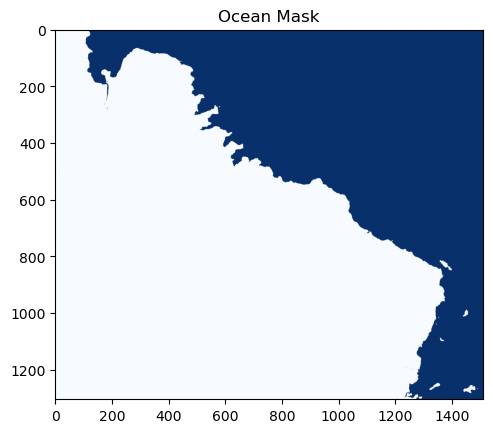

In [12]:
ocean_mask = np.where(dem_2d == 0, 1, 0)  # 1 for ocean, 0 for land

plt.imshow(ocean_mask, cmap='Blues')
plt.title('Ocean Mask')
plt.show()

In [13]:
nodata_value = -9999
dem_nodata = np.where(np.isnan(dem_2d), nodata_value, dem_2d).astype(np.float32)
# plt.imshow(dem_ndata)

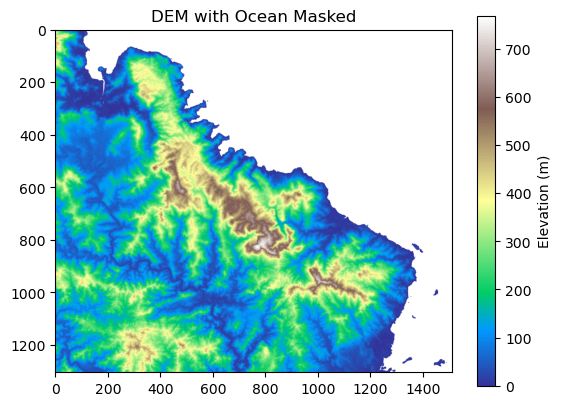

In [14]:
dem_masked = np.where(dem_nodata == 0, np.nan, dem_nodata)

# Example DEM array: ocean cells are np.nan, land is elevation
# dem_masked = np.where(dem_nodata == 0, np.nan, dem_nodata)

cmap = plt.get_cmap('terrain').copy()
cmap.set_bad(color='white')  # set color for ocean (masked np.nan)

im = plt.imshow(dem_masked, cmap=cmap)
plt.title('DEM with Ocean Masked')
cbar = plt.colorbar(im, label='Elevation (m)')

In [23]:
height, width = dem_masked.shape
left, right, bottom, top = bbox_4326

pixel_width = (right - left) / width
pixel_height = (top - bottom) / height

transform = from_origin(left, top, pixel_width, pixel_height)  # top left corner

#### 1. Write unprocssed digital elevation model to disk

##### Output: `1-dem-masked`

In [24]:
with rio.open(
    "3-dem-masked.tif", "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=dem_masked.dtype,
    crs="EPSG:32760",  # update if you know your DEM's CRS is different
    transform=transform,
    nodata=0  # or use -9999 if 0 is valid in your data
) as dst:
    dst.write(dem_masked, 1)